In [2]:
# CELL 1: Environment Setup and Google Drive Mount

!pip install -q jedi "decorator>=4.0.2,<5.0" moabb mne scikit-learn joblib

import os
import sys
import numpy as np
import mne
import moabb
from google.colab import drive

# Mount Google Drive for artifact persistence across sessions.
drive.mount('/content/drive', force_remount=False)

# Project directory for all cached data, features, and trained models.
PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'
os.makedirs(PROJECT_DIR, exist_ok=True)

print('MNE version:', mne.__version__)
print('MOABB version:', moabb.__version__)
print('NumPy version:', np.__version__)
print('Python version:', sys.version.split()[0])
print('PROJECT_DIR:', PROJECT_DIR)
print('Writable:', os.access(PROJECT_DIR, os.W_OK))

Mounted at /content/drive
MNE version: 1.11.0
MOABB version: 1.7.2
NumPy version: 2.1.3
Python version: 3.13.15
PROJECT_DIR: /content/drive/MyDrive/EEG_Quantum_Project/
Writable: True


In [3]:
# CELL 2: PhysioNetMI data ingestion, 3-band filtering, leak-free train/test split

import os
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from moabb.datasets import PhysionetMI
from moabb.paradigms import MotorImagery

# PhysioNetMI: 109 subjects, 64-channel EEG, 160 Hz native sampling rate.
dataset = PhysionetMI()

# MotorImagery paradigm segments continuous recordings into labeled trials.
# Three classes: left_hand, right_hand, rest.
paradigm = MotorImagery(
    events=['left_hand', 'right_hand', 'rest'],
    n_classes=3,
    fmin=1.0,
    fmax=79.0,
    tmin=0.0,
    tmax=4.0,
)

X_raw, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])
print('Raw X shape:', X_raw.shape)
print('Raw class distribution:', dict(zip(*np.unique(y, return_counts=True))))

sfreq = 160.0  # PhysioNetMI native sampling rate.

# Three sensorimotor-relevant bands.
# mu captures sensorimotor idle rhythm; beta captures movement-related
# desynchronization; low-gamma captures fine motor activity.
bands = {
    'mu':    (8.0, 12.0),
    'beta':  (13.0, 30.0),
    'gamma': (30.0, 40.0),
}

# Split indices ONCE so all three bands share identical folds. This is the only
# place the split is decided, guaranteeing strict cross-band alignment and
# preventing any test-data leakage into CSP, QGA, or SVM training.
idx = np.arange(X_raw.shape[0])
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, stratify=y, random_state=42
)

for name, (lo, hi) in bands.items():
    # 4th-order Butterworth bandpass; filtfilt gives zero-phase filtering.
    b, a = butter(N=4, Wn=[lo, hi], btype='bandpass', fs=sfreq)
    Xf = filtfilt(b, a, X_raw, axis=-1).astype(np.float32)
    Xtr, Xte = Xf[idx_train], Xf[idx_test]
    np.save(os.path.join(PROJECT_DIR, 'X_train_{}.npy'.format(name)), Xtr)
    np.save(os.path.join(PROJECT_DIR, 'X_test_{}.npy'.format(name)), Xte)
    print('{} band: train {} test {}'.format(name, Xtr.shape, Xte.shape))

np.save(os.path.join(PROJECT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROJECT_DIR, 'y_test.npy'), y_test)
print('Train class counts:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test class counts:', dict(zip(*np.unique(y_test, return_counts=True))))
print('Saved to:', PROJECT_DIR)

Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
This is nemar-py 0.3.1.
Preparing to download on004362 from https://data.nemar.org/


/usr/local/lib/python3.13/dist-packages/moabb/datasets/base.py:890: RuntimeWarning: Could not fetch PhysionetMotorImagery subject 1 sourcedata from NEMAR (on004362); its load will use the dataset's own downloader. Original error: NEMAR dataset on004362 publishes no sourcedata manifest -- the original distribution is not mirrored there.
  self._prefetch_nemar_sourcedata(


This is nemar-py 0.3.1.
Preparing to download on004362 from https://data.nemar.org/


/usr/local/lib/python3.13/dist-packages/moabb/datasets/base.py:1456: RuntimeWarning: Could not fetch PhysionetMotorImagery subject 1 sourcedata from NEMAR (on004362); its load will use the dataset's own downloader. Original error: NEMAR dataset on004362 publishes no sourcedata manifest -- the original distribution is not mirrored there.
  self._prefetch_nemar_sourcedata([subject])
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'physionet.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/2.60M [00:00<?, ?B/s]

...

Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]


/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'physionet.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/2.60M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 2110c48e3106898e3dbca47e39b330637afd3d3b8bc2da3ba1e44f4ac1118137
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]
Raw X shape: (129, 64, 641)
Raw class distribution: {np.str_('left_hand'): np.int64(23), np.str_('rest'): np.int64(84), np.str_('right_hand'): np.int64(22)}
mu band: train (103, 64, 641) test (26, 64, 641)
beta band: train (103, 64, 641) test (26, 64, 641)
gamma band: train (103, 64, 641) test (26, 64, 641)
Train class counts: {np.str_('left_hand'): np.int64(18), np.str_('rest'): np.int64(67), np.str_('right_hand'): np.int64(18)}
Test class counts: {np.str_('left_hand'): np.int64(5), np.str_('rest'): np.int64(17), np.str_('right_hand'): np.int64(4)}
Saved to: /content/drive/MyDrive/EEG_Quantum_Project/


In [4]:
# CELL 3: Filter-bank CSP extraction and z-score standardization

import os
import numpy as np
import joblib
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler

BANDS = ['mu', 'beta', 'gamma']
N_COMP = 4  # 4 CSP components per band, 3 bands, 12 features total.

y_train = np.load(os.path.join(PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)

# CSP finds spatial filters that maximize the variance ratio between classes.
# log=True gives log-variance features (approximately Gaussian in dB).
# Fit is performed strictly on training data to prevent leakage.
csp_models = {}
train_feats, test_feats = [], []
for band in BANDS:
    Xtr = np.load(os.path.join(PROJECT_DIR, 'X_train_{}.npy'.format(band)))
    Xte = np.load(os.path.join(PROJECT_DIR, 'X_test_{}.npy'.format(band)))
    csp = CSP(n_components=N_COMP, reg=None, log=True, norm_trace=False)
    ftr = csp.fit_transform(Xtr, y_train)
    fte = csp.transform(Xte)
    csp_models[band] = csp
    train_feats.append(ftr)
    test_feats.append(fte)
    print('{} CSP -> train {} test {}'.format(band, ftr.shape, fte.shape))

X_train_fbcsp = np.concatenate(train_feats, axis=1).astype(np.float32)
X_test_fbcsp = np.concatenate(test_feats, axis=1).astype(np.float32)
print('Concatenated FBCSP train:', X_train_fbcsp.shape)
print('Concatenated FBCSP test:', X_test_fbcsp.shape)

# StandardScaler is essential: log-variance features have heterogeneous scales
# across components, and both the SVM and QGA fitness evaluate feature subsets
# whose scale must be comparable. Fit on training data only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fbcsp).astype(np.float32)
X_test_scaled = scaler.transform(X_test_fbcsp).astype(np.float32)

joblib.dump(csp_models, os.path.join(PROJECT_DIR, 'csp_models.joblib'))
joblib.dump(scaler, os.path.join(PROJECT_DIR, 'fbcsp_scaler.joblib'))
np.save(os.path.join(PROJECT_DIR, 'X_train_fbcsp.npy'), X_train_fbcsp)
np.save(os.path.join(PROJECT_DIR, 'X_test_fbcsp.npy'), X_test_fbcsp)
np.save(os.path.join(PROJECT_DIR, 'X_train_scaled.npy'), X_train_scaled)
np.save(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'), X_test_scaled)
print('Saved to:', PROJECT_DIR)

Computing rank from data with rank=None
    Using tolerance 2.5e+02 (2.2e-16 eps * 64 dim * 1.8e+16  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=rest covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
mu CSP -> train (103, 4) test (26, 4)
Computing rank from data with rank=None
    Using tolerance 2.9e+02 (2.2e-16 eps * 64 dim * 2e+16  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=rest covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
beta CSP -> train (103, 4) test (26, 4)
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2

In [5]:
# CELL 4: Quantum Genetic Algorithm for FBCSP feature subset selection
#
# Each chromosome is a register of Q-bits. A Q-bit is a pair (alpha, beta)
# with |alpha|^2 + |beta|^2 = 1. Measurement collapses each Q-bit to a
# classical bit via the Born rule: P(bit=1) = |beta|^2. Evolution is driven
# by a quantum rotation gate that biases Q-bits toward the best individual.
# Fitness is 5-fold stratified CV macro F1 of a balanced RBF SVM on the
# selected feature subset.

import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load standardized FBCSP features and labels.
X_train = np.load(os.path.join(PROJECT_DIR, 'X_train_scaled.npy'))
X_test = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)

N_FEATURES = X_train.shape[1]
print('Feature matrix:', X_train.shape, '| N features:', N_FEATURES)

# ---------------------------------------------------------------------------
# QGA hyperparameters
# ---------------------------------------------------------------------------
POP_SIZE = 20               # Number of quantum chromosomes per generation.
N_GEN = 30                  # Number of generations.
MIN_FEATURES = 4            # Reject subsets below this size (avoids trivial solutions).
DELTA_THETA = 0.05 * np.pi  # Rotation step for Q-bit updates.
RNG = np.random.default_rng(42)

# ---------------------------------------------------------------------------
# Q-bit chromosome initialization: uniform superposition
# ---------------------------------------------------------------------------
# alpha = beta = 1/sqrt(2) gives P(bit=1) = P(bit=0) = 0.5.
alpha = np.full((POP_SIZE, N_FEATURES), 1.0 / np.sqrt(2.0))
beta = np.full((POP_SIZE, N_FEATURES), 1.0 / np.sqrt(2.0))


def measure(a_row, b_row, rng):
    # Born-rule measurement: collapse each Q-bit to a classical bit.
    prob_one = b_row ** 2
    return (rng.random(N_FEATURES) < prob_one).astype(np.int32)


def fitness(mask):
    # Fitness = 5-fold stratified CV macro F1 on the selected feature subset.
    # Macro F1 equalizes class contributions; crucial under the rest-class majority.
    if mask.sum() < MIN_FEATURES:
        return 0.0
    Xs = X_train[:, mask.astype(bool)]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    scores = cross_val_score(clf, Xs, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    return float(scores.mean())


def quantum_rotation_update(a_row, b_row, x_current, b_best, current_fit, best_fit):
    # Rotate each Q-bit toward the best individual's bit value. Rotation acts
    # on the (alpha, beta) pair as a 2D rotation by angle theta:
    #   alpha' = alpha * cos(theta) - beta * sin(theta)
    #   beta'  = alpha * sin(theta) + beta * cos(theta)
    # If the current individual is already better than the best, rotate away
    # (sign flip) to preserve population diversity.
    for j in range(N_FEATURES):
        if x_current[j] == b_best[j]:
            continue  # Already aligned; no update needed.
        sign = 1.0 if b_best[j] == 1 else -1.0
        if current_fit > best_fit:
            sign = -sign
        theta = sign * DELTA_THETA
        a_new = a_row[j] * np.cos(theta) - b_row[j] * np.sin(theta)
        b_new = a_row[j] * np.sin(theta) + b_row[j] * np.cos(theta)
        a_row[j] = a_new
        b_row[j] = b_new


# ---------------------------------------------------------------------------
# QGA main loop
# ---------------------------------------------------------------------------
best_mask = None
best_fit = -1.0
history = []

for gen in range(N_GEN):
    # Measure the full population to classical bit strings.
    masks = np.array([measure(alpha[i], beta[i], RNG) for i in range(POP_SIZE)])
    fits = np.array([fitness(m) for m in masks])

    # Track the generation best.
    idx_best = int(np.argmax(fits))
    if fits[idx_best] > best_fit:
        best_fit = float(fits[idx_best])
        best_mask = masks[idx_best].copy()

    history.append((gen, best_fit, float(fits.mean())))

    # Rotate every chromosome toward the current best individual.
    for i in range(POP_SIZE):
        quantum_rotation_update(
            alpha[i], beta[i],
            masks[i], best_mask,
            fits[i], best_fit,
        )

    print('Gen {:3d} | best CV F1 {:.4f} | mean {:.4f} | subset size {}'.format(
        gen + 1, best_fit, fits.mean(), int(best_mask.sum())))

# ---------------------------------------------------------------------------
# Persist QGA result
# ---------------------------------------------------------------------------
selected_idx = np.where(best_mask == 1)[0]
print('Final selected indices:', selected_idx.tolist())
print('Final best CV macro F1: {:.4f}'.format(best_fit))

np.save(os.path.join(PROJECT_DIR, 'qga_best_mask.npy'), best_mask)
joblib.dump(
    {'mask': best_mask, 'fitness': best_fit, 'history': history},
    os.path.join(PROJECT_DIR, 'qga_result.joblib'),
)
print('Saved to:', PROJECT_DIR)

Feature matrix: (103, 12) | N features: 12
Gen   1 | best CV F1 0.8667 | mean 0.8036 | subset size 8
Gen   2 | best CV F1 0.8667 | mean 0.7071 | subset size 8
Gen   3 | best CV F1 0.9180 | mean 0.7773 | subset size 7
Gen   4 | best CV F1 0.9180 | mean 0.8260 | subset size 7
Gen   5 | best CV F1 0.9180 | mean 0.7624 | subset size 7
Gen   6 | best CV F1 0.9522 | mean 0.7953 | subset size 7
Gen   7 | best CV F1 0.9522 | mean 0.8323 | subset size 7
Gen   8 | best CV F1 0.9522 | mean 0.7517 | subset size 7
Gen   9 | best CV F1 0.9522 | mean 0.8719 | subset size 7
Gen  10 | best CV F1 0.9522 | mean 0.8693 | subset size 7
Gen  11 | best CV F1 0.9522 | mean 0.8751 | subset size 7
Gen  12 | best CV F1 0.9522 | mean 0.8786 | subset size 7
Gen  13 | best CV F1 0.9522 | mean 0.8756 | subset size 7
Gen  14 | best CV F1 0.9522 | mean 0.8939 | subset size 7
Gen  15 | best CV F1 0.9522 | mean 0.8544 | subset size 7
Gen  16 | best CV F1 0.9522 | mean 0.8828 | subset size 7
Gen  17 | best CV F1 0.9522 |

In [6]:
# CELL 5: SVM on QGA-selected features vs full-feature baseline

import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
)

# Load standardized features and the QGA mask.
X_train = np.load(os.path.join(PROJECT_DIR, 'X_train_scaled.npy'))
X_test = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)

classes = ['left_hand', 'right_hand', 'rest']
print('Selected features: {} / {}'.format(int(mask.sum()), len(mask)))

# Majority-class baseline for reference.
majority_class = np.unique(y_train)[
    np.bincount(np.unique(y_train, return_inverse=True)[1]).argmax()
]
baseline_acc = accuracy_score(y_test, np.full_like(y_test, majority_class))
print('Majority-class baseline accuracy: {:.4f}'.format(baseline_acc))

# Hyperparameter grid for the balanced RBF SVM.
param_grid = {
    'C':     [0.1, 1.0, 10.0, 100.0, 1000.0],
    'gamma': ['scale', 0.01, 0.1, 1.0, 10.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def fit_and_report(X_tr, X_te, tag):
    base = SVC(
        kernel='rbf', probability=True,
        class_weight='balanced', random_state=42,
    )
    grid = GridSearchCV(base, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_tr, y_train)
    model = grid.best_estimator_
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print('--- {} ---'.format(tag))
    print('Best params:', grid.best_params_)
    print('CV f1_macro: {:.4f}'.format(grid.best_score_))
    print('Test accuracy: {:.4f}'.format(acc))
    print('Test macro F1: {:.4f}'.format(f1m))
    print(classification_report(y_test, y_pred, labels=classes, digits=4, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(y_test, y_pred, labels=classes))
    return model


# Full-feature baseline.
full_model = fit_and_report(X_train, X_test, 'FULL FBCSP (12 features) + SVM')

# QGA-selected subset.
qga_model = fit_and_report(
    X_train[:, mask], X_test[:, mask],
    'QGA-SELECTED ({} features) + SVM'.format(int(mask.sum())),
)

# Persist both classifiers.
joblib.dump(full_model, os.path.join(PROJECT_DIR, 'svm_full_qga.joblib'))
joblib.dump(qga_model, os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))
print('Saved models to:', PROJECT_DIR)

Selected features: 7 / 12
Majority-class baseline accuracy: 0.6538
--- FULL FBCSP (12 features) + SVM ---
Best params: {'C': 10.0, 'gamma': 0.01}
CV f1_macro: 0.8983
Test accuracy: 0.7308
Test macro F1: 0.6245
              precision    recall  f1-score   support

   left_hand     0.8000    0.8000    0.8000         5
  right_hand     0.2500    0.2500    0.2500         4
        rest     0.8235    0.8235    0.8235        17

    accuracy                         0.7308        26
   macro avg     0.6245    0.6245    0.6245        26
weighted avg     0.7308    0.7308    0.7308        26

Confusion matrix (rows=true, cols=pred):
[[ 4  0  1]
 [ 1  1  2]
 [ 0  3 14]]
--- QGA-SELECTED (7 features) + SVM ---
Best params: {'C': 1.0, 'gamma': 'scale'}
CV f1_macro: 0.9522
Test accuracy: 0.7692
Test macro F1: 0.6476
              precision    recall  f1-score   support

   left_hand     0.8000    0.8000    0.8000         5
  right_hand     0.3333    0.2500    0.2857         4
        rest     0.833

PhysioNetMI Subject 1 - 3-class motor imagery
Method                              Accuracy   Macro F1
Majority-class baseline             0.6538     n/a
Full FBCSP (12 features) + SVM      0.7308     0.6245
QGA-selected (7 features) + SVM     0.7692     0.6476
QGA-selected indices: [1, 2, 4, 6, 7, 8, 9]


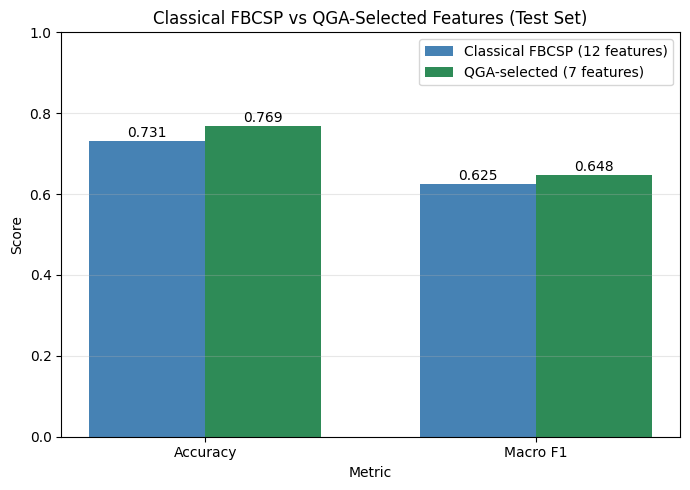

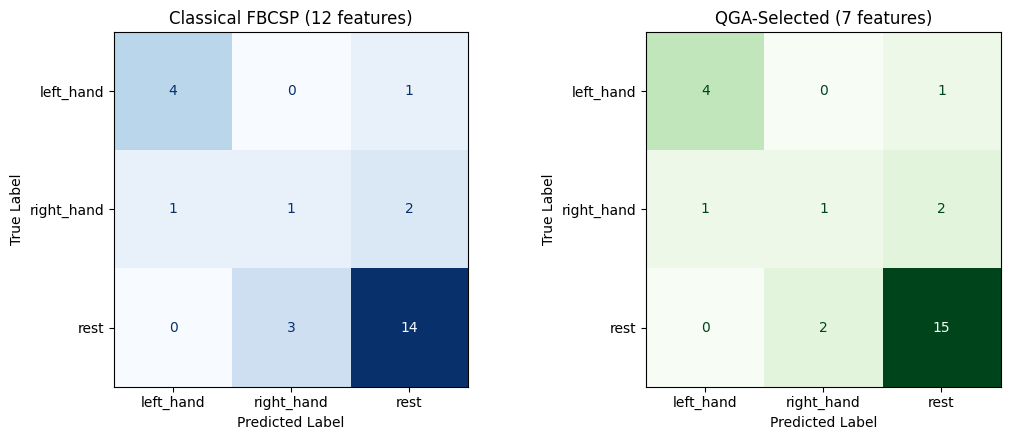

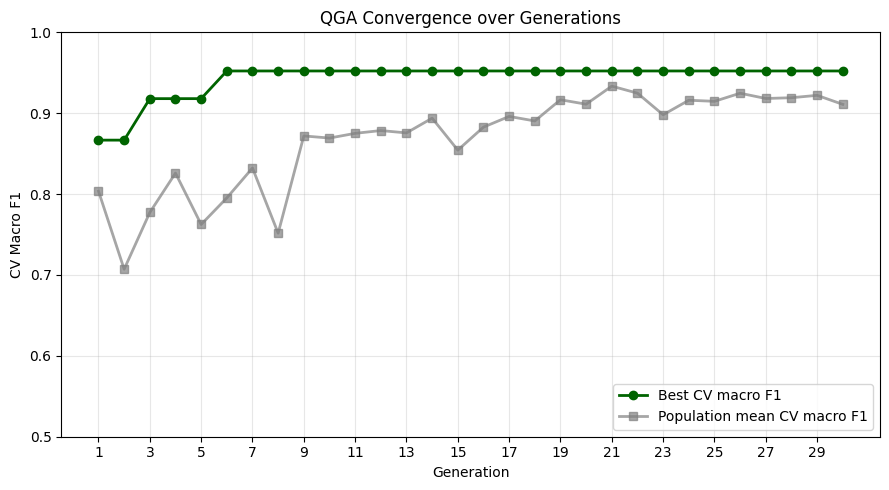

Figures saved to: /content/drive/MyDrive/EEG_Quantum_Project/


In [7]:
# CELL 6: Results summary with all visualizations

import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
)

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'
classes = ['left_hand', 'right_hand', 'rest']

X_test = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)
full_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_full_qga.joblib'))
qga_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))
qga_result = joblib.load(os.path.join(PROJECT_DIR, 'qga_result.joblib'))

pred_full = full_model.predict(X_test)
pred_qga = qga_model.predict(X_test[:, mask])

majority_class = np.unique(y_train)[
    np.bincount(np.unique(y_train, return_inverse=True)[1]).argmax()
]
baseline_acc = accuracy_score(y_test, np.full_like(y_test, majority_class))
full_acc = accuracy_score(y_test, pred_full)
full_f1 = f1_score(y_test, pred_full, average='macro', zero_division=0)
qga_acc = accuracy_score(y_test, pred_qga)
qga_f1 = f1_score(y_test, pred_qga, average='macro', zero_division=0)

# Text summary.
print('PhysioNetMI Subject 1 - 3-class motor imagery')
print('Method                              Accuracy   Macro F1')
print('Majority-class baseline             {:.4f}     n/a'.format(baseline_acc))
print('Full FBCSP (12 features) + SVM      {:.4f}     {:.4f}'.format(full_acc, full_f1))
print('QGA-selected (7 features) + SVM     {:.4f}     {:.4f}'.format(qga_acc, qga_f1))
print('QGA-selected indices: {}'.format(np.where(mask)[0].tolist()))

# ---------------------------------------------------------------------------
# Figure 1: Classical FBCSP vs QGA - accuracy and macro F1 grouped bars.
# ---------------------------------------------------------------------------
fig1, ax = plt.subplots(figsize=(7, 5))
labels = ['Accuracy', 'Macro F1']
classical_vals = [full_acc, full_f1]
qga_vals = [qga_acc, qga_f1]

x = np.arange(len(labels))
width = 0.35
bars1 = ax.bar(x - width / 2, classical_vals, width,
               label='Classical FBCSP (12 features)', color='steelblue')
bars2 = ax.bar(x + width / 2, qga_vals, width,
               label='QGA-selected (7 features)', color='seagreen')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            '{:.3f}'.format(bar.get_height()), ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            '{:.3f}'.format(bar.get_height()), ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_ylim(0, 1.0)
ax.set_title('Classical FBCSP vs QGA-Selected Features (Test Set)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'classical_vs_qga.png'), dpi=150)
plt.show()

# ---------------------------------------------------------------------------
# Figure 2: Side-by-side confusion matrices.
# ---------------------------------------------------------------------------
fig2, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cm_full = confusion_matrix(y_test, pred_full, labels=classes)
cm_qga = confusion_matrix(y_test, pred_qga, labels=classes)

disp_full = ConfusionMatrixDisplay(cm_full, display_labels=classes)
disp_full.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Classical FBCSP (12 features)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

disp_qga = ConfusionMatrixDisplay(cm_qga, display_labels=classes)
disp_qga.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('QGA-Selected (7 features)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

# ---------------------------------------------------------------------------
# Figure 3: QGA convergence - best and mean CV macro F1 per generation.
# ---------------------------------------------------------------------------
history = qga_result['history']  # list of (gen, best_fit, mean_fit)
gens = [h[0] + 1 for h in history]
best_curve = [h[1] for h in history]
mean_curve = [h[2] for h in history]

fig3, ax3 = plt.subplots(figsize=(9, 5))
ax3.plot(gens, best_curve, marker='o', linewidth=2,
         label='Best CV macro F1', color='darkgreen')
ax3.plot(gens, mean_curve, marker='s', linewidth=2, alpha=0.7,
         label='Population mean CV macro F1', color='gray')
ax3.set_xlabel('Generation')
ax3.set_ylabel('CV Macro F1')
ax3.set_title('QGA Convergence over Generations')
ax3.set_xticks(range(1, len(gens) + 1, 2))
ax3.set_ylim(0.5, 1.0)
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'qga_convergence.png'), dpi=150)
plt.show()

print('Figures saved to:', PROJECT_DIR)

In [8]:
# CELL 7: Statistical significance testing (McNemar) and bootstrap confidence intervals

!pip install -q statsmodels

import os
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'

# Load predictions and ground truth.
X_test = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)
full_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_full_qga.joblib'))
qga_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))

pred_full = full_model.predict(X_test)
pred_qga = qga_model.predict(X_test[:, mask])


# ---------------------------------------------------------------------------
# 1. McNemar's test: paired comparison of QGA vs full FBCSP on the same test set
# ---------------------------------------------------------------------------
# McNemar compares two classifiers on paired predictions. It tests whether the
# disagreement between them (n01 vs n10) is significantly asymmetric.
# Null hypothesis: the two classifiers have the same error rate.
correct_full = (pred_full == y_test)
correct_qga = (pred_qga == y_test)

n00 = int(((~correct_full) & (~correct_qga)).sum())  # both wrong
n01 = int(((~correct_full) & (correct_qga)).sum())   # full wrong, QGA right
n10 = int((correct_full & (~correct_qga)).sum())     # full right, QGA wrong
n11 = int((correct_full & correct_qga).sum())        # both right

table = [[n00, n01], [n10, n11]]
result_exact = mcnemar(table, exact=True)
result_asym = mcnemar(table, correction=True)

print('McNemar contingency table [[both_wrong, full_wrong_qga_right], '
      '[full_right_qga_wrong, both_right]]:')
print(table)
print('McNemar exact p-value: {:.4f}'.format(result_exact.pvalue))
print('McNemar asymptotic p-value (with continuity correction): {:.4f}'.format(
    result_asym.pvalue))
if result_exact.pvalue < 0.05:
    print('Conclusion: difference is statistically significant at alpha = 0.05.')
else:
    print('Conclusion: difference is NOT statistically significant at alpha = 0.05.')


# ---------------------------------------------------------------------------
# 2. Bootstrap 95% confidence intervals for accuracy and macro F1
# ---------------------------------------------------------------------------
# Resample test set with replacement 1000 times; report 2.5th and 97.5th
# percentiles of the resulting metrics. This is a non-parametric CI that does
# not assume normality, appropriate for small test sets.
def bootstrap_ci(pred, y, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    accs, f1s = [], []
    for _ in range(n_iter):
        idx = rng.integers(0, len(y), len(y))
        accs.append(accuracy_score(y[idx], pred[idx]))
        f1s.append(f1_score(y[idx], pred[idx], average='macro', zero_division=0))
    acc_ci = np.percentile(accs, [2.5, 97.5])
    f1_ci = np.percentile(f1s, [2.5, 97.5])
    return acc_ci, f1_ci

acc_full_ci, f1_full_ci = bootstrap_ci(pred_full, y_test)
acc_qga_ci, f1_qga_ci = bootstrap_ci(pred_qga, y_test)

print()
print('Bootstrap 95% confidence intervals (1000 resamples):')
print('{:<28} {:>22} {:>22}'.format('Method', 'Accuracy 95% CI', 'Macro F1 95% CI'))
print('{:<28} {:>22} {:>22}'.format(
    'Full FBCSP (12 feat)',
    '[{:.4f}, {:.4f}]'.format(acc_full_ci[0], acc_full_ci[1]),
    '[{:.4f}, {:.4f}]'.format(f1_full_ci[0], f1_full_ci[1]),
))
print('{:<28} {:>22} {:>22}'.format(
    'QGA-selected (7 feat)',
    '[{:.4f}, {:.4f}]'.format(acc_qga_ci[0], acc_qga_ci[1]),
    '[{:.4f}, {:.4f}]'.format(f1_qga_ci[0], f1_qga_ci[1]),
))
print()
print('Interpretation: the 26-sample test set produces wide CIs. Overlapping')
print('intervals indicate that the observed QGA advantage is within sampling noise,')
print('which motivates the McNemar result above for a paired comparison.')

McNemar contingency table [[both_wrong, full_wrong_qga_right], [full_right_qga_wrong, both_right]]:
[[6, 1], [0, 19]]
McNemar exact p-value: 1.0000
McNemar asymptotic p-value (with continuity correction): 1.0000
Conclusion: difference is NOT statistically significant at alpha = 0.05.

Bootstrap 95% confidence intervals (1000 resamples):
Method                              Accuracy 95% CI        Macro F1 95% CI
Full FBCSP (12 feat)               [0.5385, 0.8846]       [0.4032, 0.8107]
QGA-selected (7 feat)              [0.5769, 0.9231]       [0.4157, 0.8352]

Interpretation: the 26-sample test set produces wide CIs. Overlapping
intervals indicate that the observed QGA advantage is within sampling noise,
which motivates the McNemar result above for a paired comparison.


In [9]:
# CELL 8: Gradio UI with balanced random sampling and manual EEG input

!pip install -q gradio

import os
import re
import numpy as np
import joblib
import gradio as gr
from scipy.signal import butter, filtfilt

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'
BANDS = ['mu', 'beta', 'gamma']
BAND_RANGES = {'mu': (8.0, 12.0), 'beta': (13.0, 30.0), 'gamma': (30.0, 40.0)}
SFREQ = 160.0
N_COMP = 4
N_CHANNELS = 64

qga_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))
csp_models = joblib.load(os.path.join(PROJECT_DIR, 'csp_models.joblib'))
scaler = joblib.load(os.path.join(PROJECT_DIR, 'fbcsp_scaler.joblib'))
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)
X_test_scaled = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)

DISPLAY = {'left_hand': 'Left Hand', 'right_hand': 'Right Hand', 'rest': 'Rest'}

unique_classes = np.unique(y_test)
class_indices = {c: np.where(y_test == c)[0] for c in unique_classes}

band_labels = []
for band in BANDS:
    for k in range(N_COMP):
        band_labels.append('{}_CSP{}'.format(band, k))
selected_names = [band_labels[i] for i in range(len(mask)) if mask[i]]


def _format_probs(probs):
    return {DISPLAY[c]: float(p) for c, p in zip(qga_model.classes_, probs)}


def _run_pipeline_on_trial(arr):
    # arr: (1, 64, n_times) raw EEG; runs the full filter -> CSP -> scale -> QGA-mask path.
    band_feats = []
    for band in BANDS:
        lo, hi = BAND_RANGES[band]
        b, a = butter(N=4, Wn=[lo, hi], btype='bandpass', fs=SFREQ)
        Xf = filtfilt(b, a, arr, axis=-1)
        band_feats.append(csp_models[band].transform(Xf))
    csp_vec = np.concatenate(band_feats, axis=1).astype(np.float32)
    csp_scaled = scaler.transform(csp_vec).astype(np.float32)
    x = csp_scaled[:, mask]
    probs = qga_model.predict_proba(x)[0]
    pred = qga_model.classes_[int(np.argmax(probs))]
    return pred, probs


def predict_random():
    c = unique_classes[np.random.randint(0, len(unique_classes))]
    i = int(np.random.choice(class_indices[c]))
    x = X_test_scaled[i:i + 1, mask]
    probs = qga_model.predict_proba(x)[0]
    pred = qga_model.classes_[int(np.argmax(probs))]
    gt = str(y_test[i])
    correct = 'Correct' if pred == gt else 'Incorrect'
    info = (
        'Sample index: {}\n'
        'Drawn class: {}\n'
        'Ground truth: {}\n'
        'QGA selected {} of 12 features for this decision: {}'
    ).format(i, DISPLAY[c], DISPLAY[gt], int(mask.sum()), ', '.join(selected_names))
    return DISPLAY[pred], correct, _format_probs(probs), info


def _parse_manual_input(text):
    # Accept comma, whitespace, or newline separated numeric values.
    # Returns a flat float array or raises on unparsable input.
    tokens = re.split(r'[,\s]+', text.strip())
    tokens = [t for t in tokens if t]
    if not tokens:
        raise ValueError('No numeric values found.')
    return np.array([float(t) for t in tokens], dtype=np.float32)


def predict_from_manual(text):
    if not text or not text.strip():
        return 'Empty input', 'Paste EEG values (see format help above).', {}
    try:
        vals = _parse_manual_input(text)
    except Exception as exc:
        return 'Parse error', 'Could not parse values: {}'.format(exc), {}

    # Two accepted layouts:
    #   - Flat vector of 64 * n_times values (row-major, channels first)
    #   - Already shaped 64 x n_times (same flat count)
    # Both reduce to a flat array; we infer n_times from the total length.
    if vals.size % N_CHANNELS != 0:
        return (
            'Invalid length',
            'Expected a multiple of {} values (64 channels x n_times). '
            'Got {} values.'.format(N_CHANNELS, vals.size),
            {},
        )

    n_times = vals.size // N_CHANNELS
    arr = vals.reshape(N_CHANNELS, n_times)[np.newaxis, :, :]

    try:
        pred, probs = _run_pipeline_on_trial(arr)
    except Exception as exc:
        return 'Inference error', str(exc), {}

    info = (
        'Manual input parsed.\n'
        'Channels: {}\n'
        'Time samples: {}\n'
        'At {} Hz this corresponds to {:.2f} seconds of signal.\n'
        'QGA selected {} of 12 features: {}'
    ).format(
        N_CHANNELS, n_times, SFREQ, n_times / SFREQ,
        int(mask.sum()), ', '.join(selected_names),
    )
    return DISPLAY[pred], info, _format_probs(probs)


CSS = """
.gradio-container { max-width: 940px !important; margin: auto !important; }
.header-title { font-size: 22px; font-weight: 600; color: #1e293b; margin-bottom: 4px; }
.header-sub { font-size: 14px; color: #64748b; margin-bottom: 20px; line-height: 1.5; }
.helper { font-size: 13px; color: #334155; background: #f1f5f9;
          border-left: 3px solid #64748b; padding: 10px 14px;
          border-radius: 4px; margin-bottom: 12px; line-height: 1.6; }
.footer { font-size: 12px; color: #94a3b8; margin-top: 24px; text-align: center; }
"""

with gr.Blocks(css=CSS, title='EEG Motor-Imagery Classifier', theme=gr.themes.Soft()) as demo:

    gr.HTML(
        '<div class="header-title">EEG Motor-Imagery Classifier</div>'
        '<div class="header-sub">'
        'FBCSP feature extraction with Quantum Genetic Algorithm (QGA) selection, '
        'classified by an RBF SVM. Trained on PhysioNetMI Subject 1. '
        'Three classes: left hand, right hand, rest.'
        '</div>'
    )

    with gr.Tab('Random Sample'):
        gr.Markdown(
            'Draw a random trial from the held-out test set. Sampling is balanced '
            'across the three classes so each class appears equally often.'
        )
        btn = gr.Button('Classify a Random Trial', variant='primary', size='lg')
        with gr.Row():
            out_pred = gr.Textbox(label='Predicted Class', interactive=False)
            out_result = gr.Textbox(label='Result', interactive=False)
        out_probs = gr.Label(label='Class Probabilities', num_top_classes=3)
        out_info = gr.Textbox(label='Details', interactive=False, lines=5)
        btn.click(predict_random, inputs=None,
                  outputs=[out_pred, out_result, out_probs, out_info])

    with gr.Tab('Manual EEG Input'):
        gr.HTML(
            '<div class="helper">'
            '<b>Input format:</b> paste EEG values as a flat list separated by '
            'commas, spaces, or newlines. Values are interpreted in row-major order: '
            'the first 64 values are one time sample across 64 channels, the next 64 '
            'are the next time sample, and so on. The total count must be a multiple '
            'of 64. Example: 64 channels x 641 samples at 160 Hz = 4 seconds of signal, '
            'requiring 41,024 values.<br><br>'
            'Smaller time windows are accepted (e.g. 64 x 320 = 2 seconds), but '
            'shorter windows may reduce feature quality.'
            '</div>'
        )
        manual_in = gr.Textbox(
            label='EEG Values',
            placeholder='0.012, -0.034, 0.008, ...',
            lines=8,
        )
        manual_btn = gr.Button('Classify Manual Input', variant='primary')
        with gr.Row():
            m_pred = gr.Textbox(label='Predicted Class', interactive=False)
        m_probs = gr.Label(label='Class Probabilities', num_top_classes=3)
        m_info = gr.Textbox(label='Details', interactive=False, lines=6)
        manual_btn.click(predict_from_manual, inputs=manual_in,
                         outputs=[m_pred, m_info, m_probs])

    with gr.Accordion('Model Information', open=False):
        gr.Markdown(
            '- **Pipeline**: 3-band filterbank (mu 8-12 Hz, beta 13-30 Hz, '
            'gamma 30-40 Hz), CSP with 4 components per band, 12 features total.\n'
            '- **Feature selection**: Quantum Genetic Algorithm selected '
            '{} of 12 features.\n'.format(int(mask.sum())) +
            '- **Selected features**: ' + ', '.join(selected_names) + '\n'
            '- **Classifier**: RBF SVM with balanced class weights.\n'
            '- **Test set**: 26 held-out trials, 20% stratified split, random_state=42.\n'
            '- **Channels**: 64 EEG electrodes in PhysioNetMI order '
            '(standard 10-20 montage).'
        )

    gr.HTML('<div class="footer">PhysioNetMI Subject 1 | 3-class motor imagery</div>')

demo.launch(share=True, debug=False)

/tmp/ipykernel_770/381256975.py:136: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=CSS, title='EEG Motor-Imagery Classifier', theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ec4d36bf27ae51c14d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
